# Engine Result Analysis

## [0] Setup & Config

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic config ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#0F1117',
    'axes.edgecolor':   '#2A2D35',
    'axes.labelcolor':  '#9DA5B4',
    'axes.titlecolor':  '#E8EAF0',
    'axes.titlesize':   13,
    'axes.titlepad':    12,
    'axes.labelsize':   11,
    'xtick.color':      '#6B7280',
    'ytick.color':      '#6B7280',
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'grid.color':       '#1E2028',
    'grid.linestyle':   '-',
    'grid.linewidth':   0.8,
    'text.color':       '#E8EAF0',
    'font.family':      'monospace',
    'figure.dpi':       120,
    'legend.facecolor': '#1A1D27',
    'legend.edgecolor': '#2A2D35',
})

# ── Version colour palette ────────────────────────────────────────────────────
VERSION_COLORS = {
    'v1': '#4D9EFF',   # blue
    'v2': '#00D68F',   # green
    'v3': '#FFD166',   # yellow
    'v4': '#A78BFA',   # purple  ← optimal
    'v5': '#FF4D6A',   # red
}
VERSION_LABELS = {
    'v1': 'v1 — Baseline',
    'v2': 'v2 — Risk Mgmt',
    'v3': 'v3 — Time Filter',
    'v4': 'v4 — Selectivity ★',
    'v5': 'v5 — Extreme',
}
VERSIONS = ['v1', 'v2', 'v3', 'v4', 'v5']

# ── Shared palette ────────────────────────────────────────────────────────────
GREEN  = '#00D68F'
RED    = '#FF4D6A'
BLUE   = '#4D9EFF'
YELLOW = '#FFD166'
GRAY   = '#4B5563'
BG     = '#0F1117'

print('✅ Setup complete.')


✅ Setup complete.


## [1] Load & Parse All Versions

In [ ]:
# ── File map — update paths here if needed ────────────────────────────────────
CSV_FILES = {
    'v1': 'updated_v1_baseline_model_result.csv',
    'v2': 'updated_v2_trade_ result.csv',
    'v3': 'updated_v3_trade_result.csv',
    'v4': 'updated_v4_trade_result.csv',
    'v5': 'updated_v5_trade_result.csv',
}

dfs = {}   # raw dataframes per version

for ver, path in CSV_FILES.items():
    df = pd.read_csv(path)
    df['entry_datetime'] = pd.to_datetime(df['entry_datetime'], utc=True).dt.tz_convert('America/New_York')
    df['exit_datetime']  = pd.to_datetime(df['exit_datetime'],  utc=True).dt.tz_convert('America/New_York')
    df['div_born_at']    = pd.to_datetime(df['div_born_at'],    utc=True).dt.tz_convert('America/New_York')

    df['year']         = df['entry_datetime'].dt.year
    df['month']        = df['entry_datetime'].dt.month
    df['month_name']   = df['entry_datetime'].dt.strftime('%b')
    df['dow']          = df['entry_datetime'].dt.day_name()
    df['entry_hour']   = df['entry_datetime'].dt.hour
    df['duration_hrs'] = (df['exit_datetime'] - df['entry_datetime']).dt.total_seconds() / 3600
    df['outcome']      = df['pnl_points'].apply(lambda x: 'WIN' if x > 0 else ('BE' if x == 0 else 'LOSS'))
    df['version']      = ver

    df = df.sort_values('entry_datetime').reset_index(drop=True)
    df['cumulative_pnl'] = df['pnl_points'].cumsum()
    df['trade_number']   = df.index + 1
    dfs[ver] = df
    print(f'  {ver}: {len(df):>4} trades loaded  |  Total PnL: {df["pnl_points"].sum():>8,.2f} pts')

print('\n✅ All versions loaded.')


  v1:  187 trades loaded  |  Total PnL: 6,407.00 pts
  v2:  138 trades loaded  |  Total PnL: 5,658.75 pts
  v3:   80 trades loaded  |  Total PnL: 6,009.75 pts
  v4:   67 trades loaded  |  Total PnL: 6,381.50 pts
  v5:   67 trades loaded  |  Total PnL: 5,972.50 pts

✅ All versions loaded.


## [2] Executive Summary — All Versions Side by Side

In [ ]:
# ── Compute core stats for each version ──────────────────────────────────────
summary_rows = []

for ver in VERSIONS:
    df = dfs[ver]
    winners    = df[df['pnl_points'] > 0]
    losers     = df[df['pnl_points'] < 0]
    breakevens = df[df['pnl_points'] == 0]

    win_rate   = len(winners) / len(df)
    avg_win    = winners['pnl_points'].mean()   if len(winners) > 0 else 0
    avg_loss   = abs(losers['pnl_points'].mean()) if len(losers)  > 0 else 0
    wl_ratio   = avg_win / avg_loss if avg_loss > 0 else np.nan
    expectancy = (win_rate * avg_win) - ((1 - win_rate) * avg_loss)

    peak     = df['cumulative_pnl'].cummax()
    drawdown = df['cumulative_pnl'] - peak
    max_dd   = drawdown.min()

    max_consec = 0
    streak = 0
    for v in df['pnl_points']:
        streak = streak + 1 if v <= 0 else 0
        max_consec = max(max_consec, streak)

    be_trades     = df[df['breakeven_applied'] == True] if 'breakeven_applied' in df.columns else pd.DataFrame()
    be_saved      = breakevens['risk_points'].sum() if 'risk_points' in df.columns else 0
    be_cap_saved  = be_trades['risk_points'].sum() if len(be_trades) > 0 and 'risk_points' in df.columns else 0
    total_pnl     = df['pnl_points'].sum()
    organic_pct   = (total_pnl - be_cap_saved) / total_pnl * 100 if total_pnl != 0 else 0

    summary_rows.append({
        'version':       ver,
        'label':         VERSION_LABELS[ver],
        'trades':        len(df),
        'winners':       len(winners),
        'losers':        len(losers),
        'breakevens':    len(breakevens),
        'win_rate':      win_rate * 100,
        'total_pnl':     total_pnl,
        'avg_win':       avg_win,
        'avg_loss':      avg_loss,
        'wl_ratio':      wl_ratio,
        'expectancy':    expectancy,
        'max_dd':        max_dd,
        'max_consec':    max_consec,
        'be_cap_saved':  be_cap_saved,
        'organic_pct':   organic_pct,
    })

summary = pd.DataFrame(summary_rows).set_index('version')

# ── Print table ───────────────────────────────────────────────────────────────
print('=' * 100)
print(f"  {'UNIFIED STRATEGY PERFORMANCE SUMMARY — ALL VERSIONS':^96}")
print('=' * 100)
metrics = [
    ('Trades',            'trades',      '{:>6.0f}',     ''),
    ('Win Rate',          'win_rate',    '{:>6.1f}%',    ''),
    ('Total PnL (pts)',   'total_pnl',   '{:>8,.1f}',    ''),
    ('Avg Win (pts)',     'avg_win',     '{:>+8.2f}',    ''),
    ('Avg Loss (pts)',    'avg_loss',    '{:>8.2f}',     '-'),
    ('W/L Ratio',         'wl_ratio',    '{:>7.2f}x',    ''),
    ('Expectancy/Trade',  'expectancy',  '{:>+8.2f}',    ''),
    ('Max Drawdown',      'max_dd',      '{:>8,.2f}',    ''),
    ('Max Consec Loss',   'max_consec',  '{:>6.0f}',     ''),
    ('Organic PnL %',     'organic_pct', '{:>6.1f}%',    ''),
]
header = f"  {'Metric':<20}" + ''.join(f"  {v:>16}" for v in VERSIONS)
print(header)
print('-' * 100)
for label, col, fmt, prefix in metrics:
    row = f"  {label:<20}"
    for v in VERSIONS:
        val = summary.loc[v, col]
        row += f"  {prefix + fmt.format(val):>16}"
    print(row)
print('=' * 100)
print('  ★ v4 is the optimal version: highest expectancy, lowest drawdown, fewest consecutive losses.')
print('=' * 100)


                        UNIFIED STRATEGY PERFORMANCE SUMMARY — ALL VERSIONS                       
  Metric                              v1                v2                v3                v4                v5
----------------------------------------------------------------------------------------------------
  Trades                             187               138                80                67                67
  Win Rate                         19.8%             32.6%             41.2%             43.3%             35.8%
  Total PnL (pts)                6,407.0           5,658.8           6,009.8           6,381.5           5,972.5
  Avg Win (pts)                  +328.91           +223.52           +256.53           +284.54           +328.06
  Avg Loss (pts)               -   46.85         -   58.66         -   57.11         -   55.01         -   52.81
  W/L Ratio                        7.02x             3.81x             4.49x             5.17x             6.21x
  Expecta

## [3] Equity Curves — All Versions Overlaid

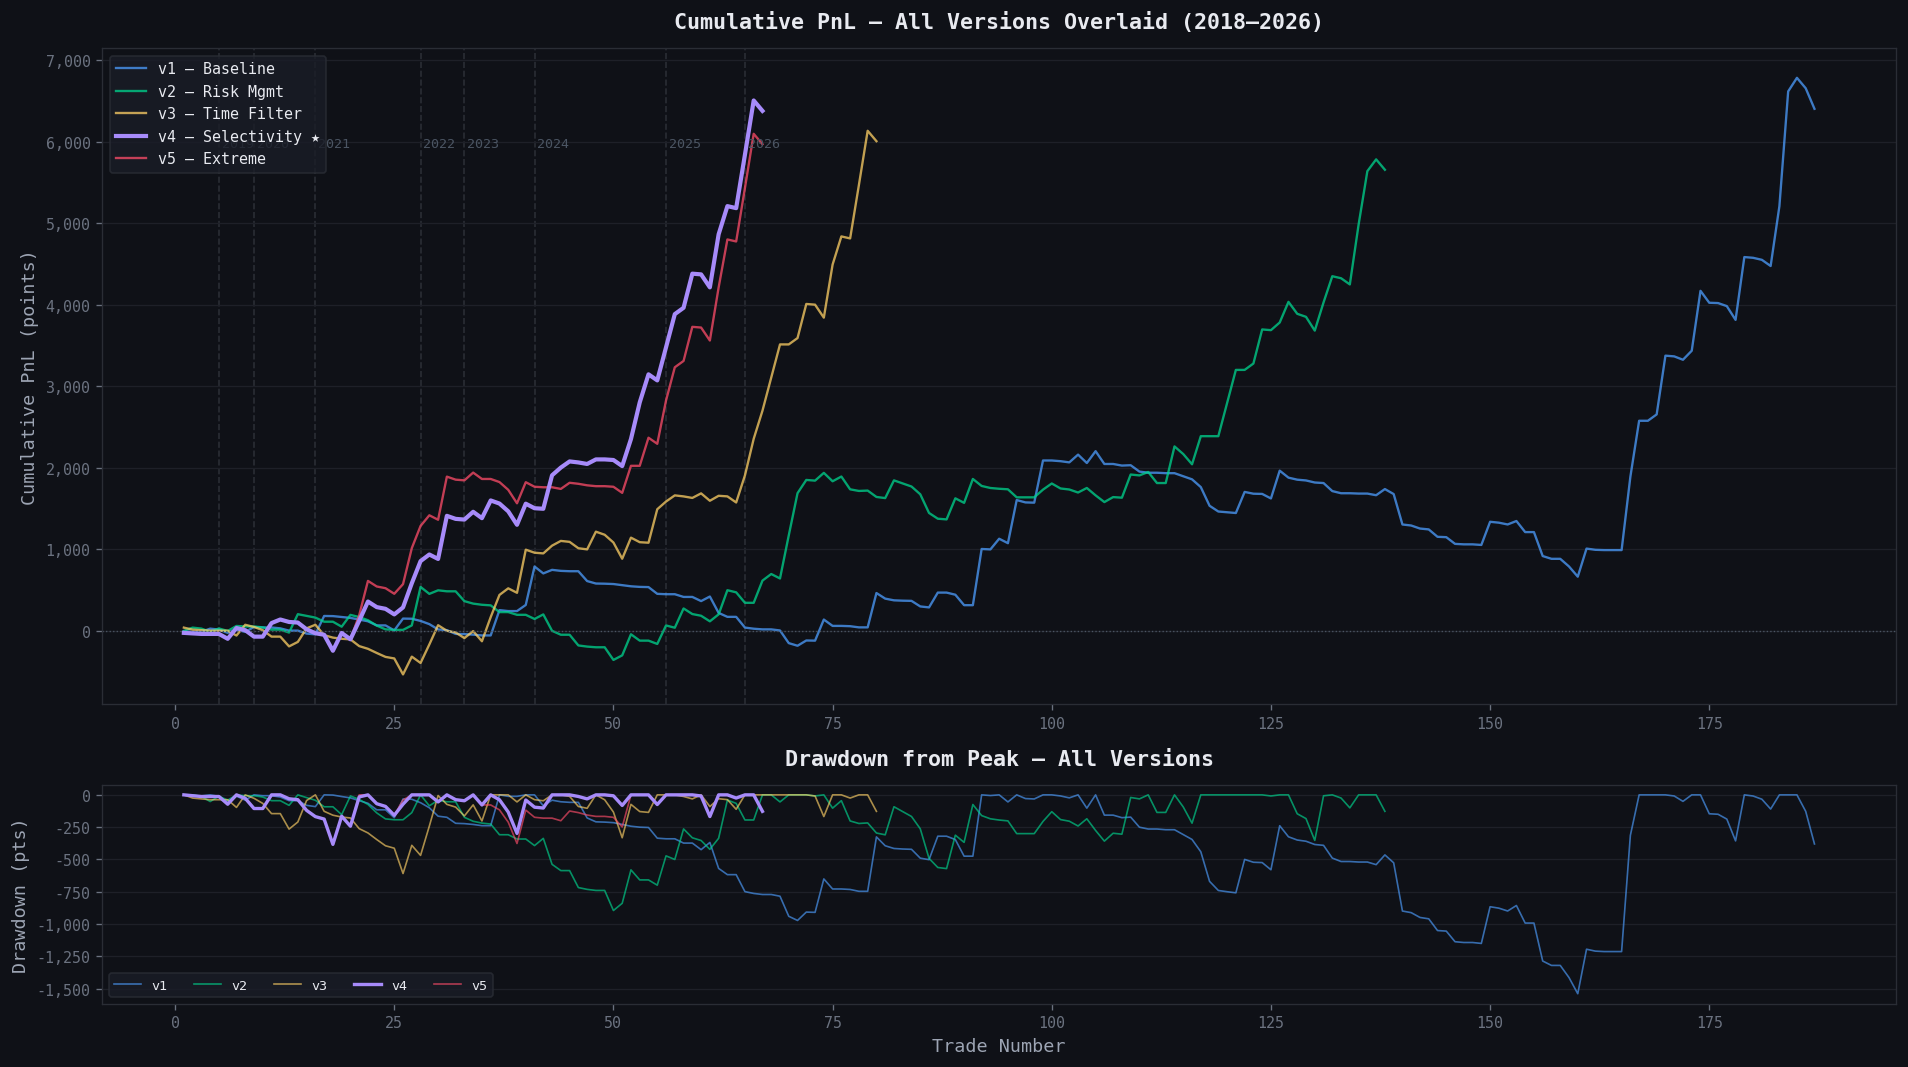

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor(BG)

# ── Equity curves ─────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor(BG)

for ver in VERSIONS:
    df  = dfs[ver]
    col = VERSION_COLORS[ver]
    lw  = 2.5 if ver == 'v4' else 1.4
    alpha = 1.0 if ver == 'v4' else 0.75
    ax1.plot(df['trade_number'], df['cumulative_pnl'],
             color=col, linewidth=lw, alpha=alpha, label=VERSION_LABELS[ver], zorder=3 if ver=='v4' else 2)

# Year markers (based on v4 dates)
df4 = dfs['v4']
for yr in range(2019, 2027):
    yr_idx = df4[df4['year'] == yr].index
    if len(yr_idx):
        tn = df4.loc[yr_idx[0], 'trade_number']
        ax1.axvline(tn, color='#2A2D35', linewidth=1, linestyle='--', zorder=1)
        ax1.text(tn + 0.3, ax1.get_ylim()[1] * 0.02 + 5800, str(yr),
                 color='#4B5563', fontsize=8)

ax1.axhline(0, color=GRAY, linewidth=0.8, linestyle=':')
ax1.set_title('Cumulative PnL — All Versions Overlaid (2018–2026)', fontweight='bold')
ax1.set_ylabel('Cumulative PnL (points)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, axis='y')

# ── Drawdown comparison ───────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG)

for ver in VERSIONS:
    df   = dfs[ver]
    peak = df['cumulative_pnl'].cummax()
    dd   = df['cumulative_pnl'] - peak
    col  = VERSION_COLORS[ver]
    lw   = 2.0 if ver == 'v4' else 1.0
    ax2.plot(df['trade_number'], dd, color=col, linewidth=lw,
             alpha=1.0 if ver=='v4' else 0.65, label=ver, zorder=3 if ver=='v4' else 2)

ax2.set_title('Drawdown from Peak — All Versions', fontweight='bold')
ax2.set_ylabel('Drawdown (pts)')
ax2.set_xlabel('Trade Number')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.legend(fontsize=8, loc='lower left', ncol=5)
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('equity_curves_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## [4] Annual Performance Breakdown

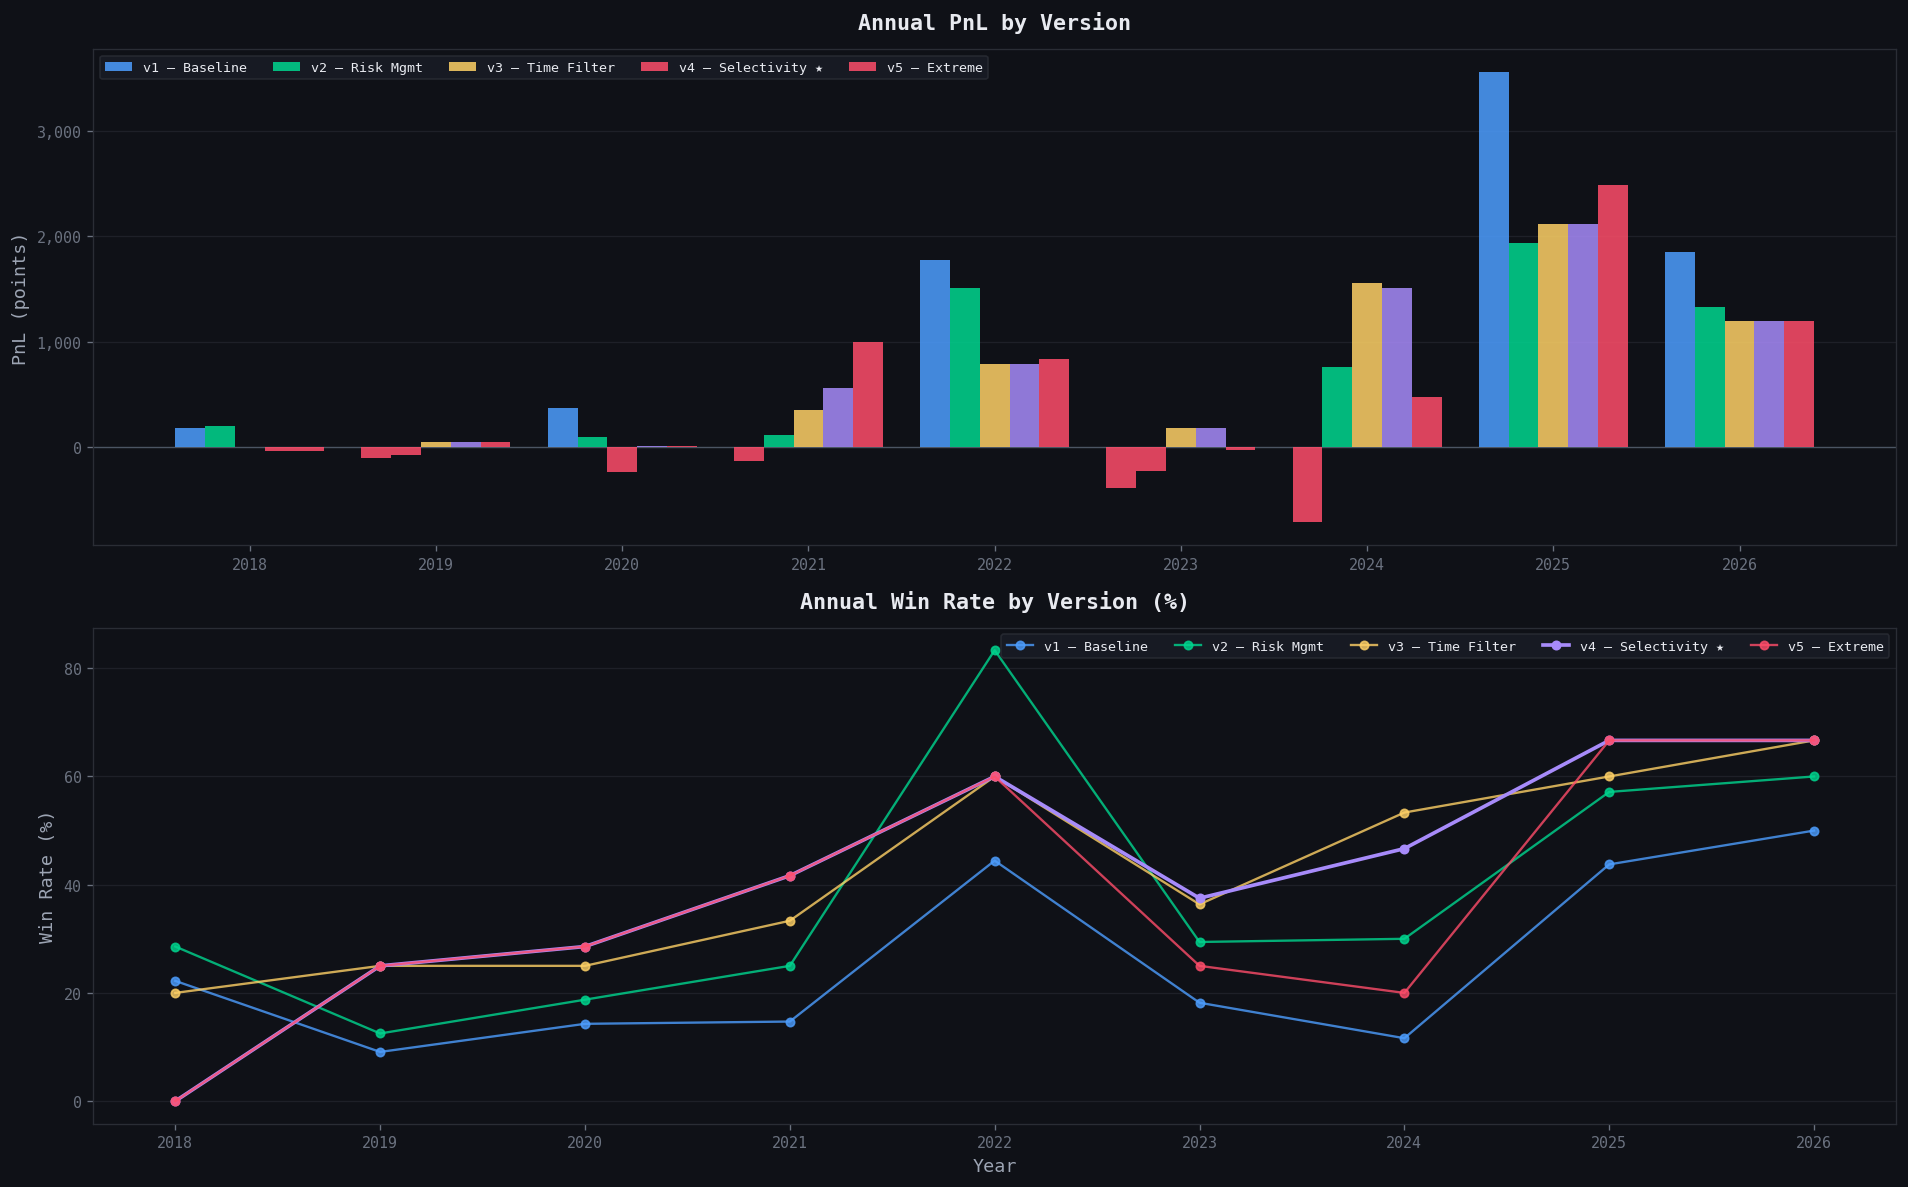


Annual PnL (pts):
          v1      v2      v3      v4      v5
2018   181.0   205.0     2.0   -38.0   -38.0
2019   -98.0   -74.0    46.0    46.0    46.0
2020   367.0   100.0  -235.0    11.0    11.0
2021  -134.0   114.0   356.0   565.0   996.0
2022  1776.0  1508.0   790.0   790.0   840.0
2023  -386.0  -226.0   185.0   186.0   -31.0
2024  -714.0   762.0  1558.0  1513.0   471.0
2025  3562.0  1938.0  2114.0  2114.0  2483.0
2026  1853.0  1331.0  1194.0  1194.0  1194.0

Annual Win Rate (%):
        v1    v2    v3    v4    v5
2018  22.2  28.6  20.0   0.0   0.0
2019   9.1  12.5  25.0  25.0  25.0
2020  14.3  18.8  25.0  28.6  28.6
2021  14.7  25.0  33.3  41.7  41.7
2022  44.4  83.3  60.0  60.0  60.0
2023  18.2  29.4  36.4  37.5  25.0
2024  11.6  30.0  53.3  46.7  20.0
2025  43.8  57.1  60.0  66.7  66.7
2026  50.0  60.0  66.7  66.7  66.7


In [ ]:
# ── Build annual PnL per version ──────────────────────────────────────────────
all_years = sorted(set(yr for ver in VERSIONS for yr in dfs[ver]['year'].unique()))
annual_pnl = {}
annual_wr  = {}

for ver in VERSIONS:
    df = dfs[ver]
    grp = df.groupby('year').agg(
        total_pnl = ('pnl_points', 'sum'),
        trades    = ('pnl_points', 'count'),
        wins      = ('outcome', lambda x: (x == 'WIN').sum()),
    ).reindex(all_years, fill_value=0)
    grp['win_rate'] = (grp['wins'] / grp['trades'].replace(0, np.nan) * 100).fillna(0)
    annual_pnl[ver] = grp['total_pnl']
    annual_wr[ver]  = grp['win_rate']

annual_df_pnl = pd.DataFrame(annual_pnl, index=all_years)
annual_df_wr  = pd.DataFrame(annual_wr,  index=all_years)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor(BG)

x    = np.arange(len(all_years))
w    = 0.16
offsets = np.linspace(-2, 2, 5) * w

# Annual PnL grouped bars
ax1 = axes[0]
ax1.set_facecolor(BG)
for i, ver in enumerate(VERSIONS):
    vals   = annual_df_pnl[ver].values
    colors = [VERSION_COLORS[ver] if v >= 0 else RED for v in vals]
    bars   = ax1.bar(x + offsets[i], vals, width=w, color=colors,
                     label=VERSION_LABELS[ver], alpha=0.85, zorder=3)

ax1.axhline(0, color=GRAY, linewidth=0.8)
ax1.set_title('Annual PnL by Version', fontweight='bold')
ax1.set_ylabel('PnL (points)')
ax1.set_xticks(x)
ax1.set_xticklabels(all_years)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=8, ncol=5)
ax1.grid(True, axis='y', zorder=0)

# Annual win rate lines
ax2 = axes[1]
ax2.set_facecolor(BG)
for ver in VERSIONS:
    lw = 2.2 if ver == 'v4' else 1.4
    ax2.plot(all_years, annual_df_wr[ver].values,
             color=VERSION_COLORS[ver], linewidth=lw, marker='o', markersize=5,
             label=VERSION_LABELS[ver], alpha=1.0 if ver=='v4' else 0.8)

ax2.set_title('Annual Win Rate by Version (%)', fontweight='bold')
ax2.set_ylabel('Win Rate (%)')
ax2.set_xlabel('Year')
ax2.set_xticks(all_years)
ax2.legend(fontsize=8, ncol=5)
ax2.grid(True, axis='y', zorder=0)

plt.tight_layout()
plt.savefig('annual_breakdown.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Print table ───────────────────────────────────────────────────────────────
print('\nAnnual PnL (pts):')
print(annual_df_pnl.round(0).to_string())
print('\nAnnual Win Rate (%):')
print(annual_df_wr.round(1).to_string())


## [5] Win Rate & Expectancy Evolution

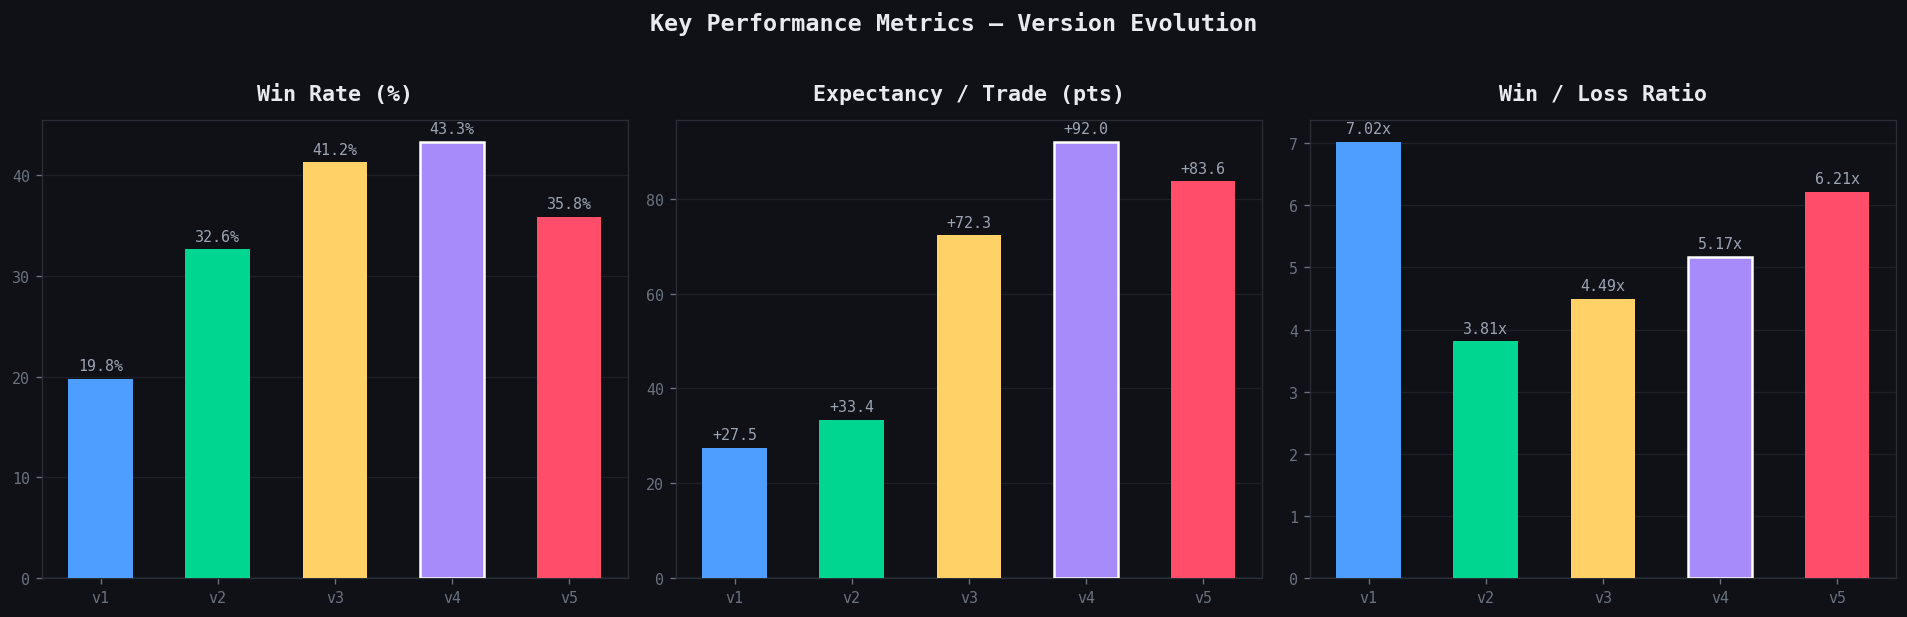

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

metrics_to_plot = [
    ('win_rate',   'Win Rate (%)',          '{:.1f}%'),
    ('expectancy', 'Expectancy / Trade (pts)', '{:+.1f}'),
    ('wl_ratio',   'Win / Loss Ratio',       '{:.2f}x'),
]

for ax, (col, title, fmt) in zip(axes, metrics_to_plot):
    ax.set_facecolor(BG)
    vals   = [summary.loc[v, col] for v in VERSIONS]
    colors = [VERSION_COLORS[v] for v in VERSIONS]
    bars   = ax.bar(VERSIONS, vals, color=colors, width=0.55, zorder=3)

    for bar, val in zip(bars, vals):
        ypos = bar.get_height() + abs(max(vals)) * 0.02
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                fmt.format(val), ha='center', fontsize=9, color='#9DA5B4')

    # Highlight v4
    bars[3].set_edgecolor('white')
    bars[3].set_linewidth(1.5)

    ax.axhline(0, color=GRAY, linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, axis='y', zorder=0)
    ax.set_xticks(range(len(VERSIONS)))
    ax.set_xticklabels(VERSIONS)

plt.suptitle('Key Performance Metrics — Version Evolution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metrics_evolution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## [6] Drawdown Comparison

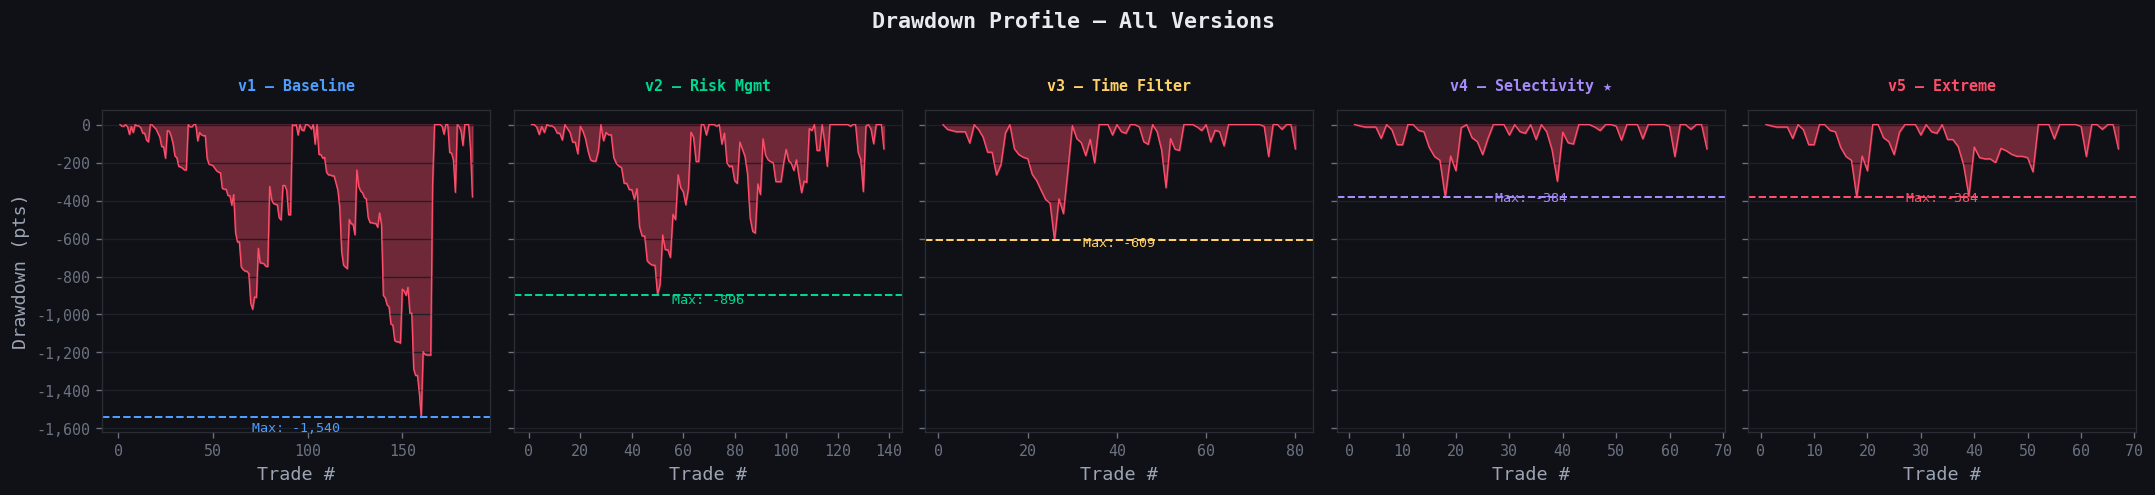


Max Drawdown Summary:
  v1:  -1,540.25 pts   (max consec losses: 17)
  v2:    -895.75 pts   (max consec losses: 11)
  v3:    -609.25 pts   (max consec losses: 10)
  v4:    -383.50 pts   (max consec losses: 6)
  v5:    -383.50 pts   (max consec losses: 6)


In [ ]:
fig, axes = plt.subplots(1, len(VERSIONS), figsize=(18, 4), sharey=True)
fig.patch.set_facecolor(BG)

for ax, ver in zip(axes, VERSIONS):
    df   = dfs[ver]
    col  = VERSION_COLORS[ver]
    peak = df['cumulative_pnl'].cummax()
    dd   = df['cumulative_pnl'] - peak
    max_dd = dd.min()

    ax.set_facecolor(BG)
    ax.fill_between(df['trade_number'], dd, alpha=0.4, color=RED)
    ax.plot(df['trade_number'], dd, color=RED, linewidth=0.8)
    ax.axhline(max_dd, color=col, linewidth=1.2, linestyle='--')
    ax.text(df['trade_number'].mean(), max_dd * 1.05,
            f'Max: {max_dd:,.0f}', ha='center', fontsize=8, color=col)

    ax.set_title(f'{VERSION_LABELS[ver]}', fontweight='bold', fontsize=9, color=col)
    ax.set_xlabel('Trade #')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(True, axis='y')

axes[0].set_ylabel('Drawdown (pts)')
plt.suptitle('Drawdown Profile — All Versions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('drawdown_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('\nMax Drawdown Summary:')
for ver in VERSIONS:
    df   = dfs[ver]
    peak = df['cumulative_pnl'].cummax()
    dd   = df['cumulative_pnl'] - peak
    print(f'  {ver}: {dd.min():>10,.2f} pts   (max consec losses: {summary.loc[ver,"max_consec"]:.0f})')


## [7] Entry Type Analysis — asset vs base

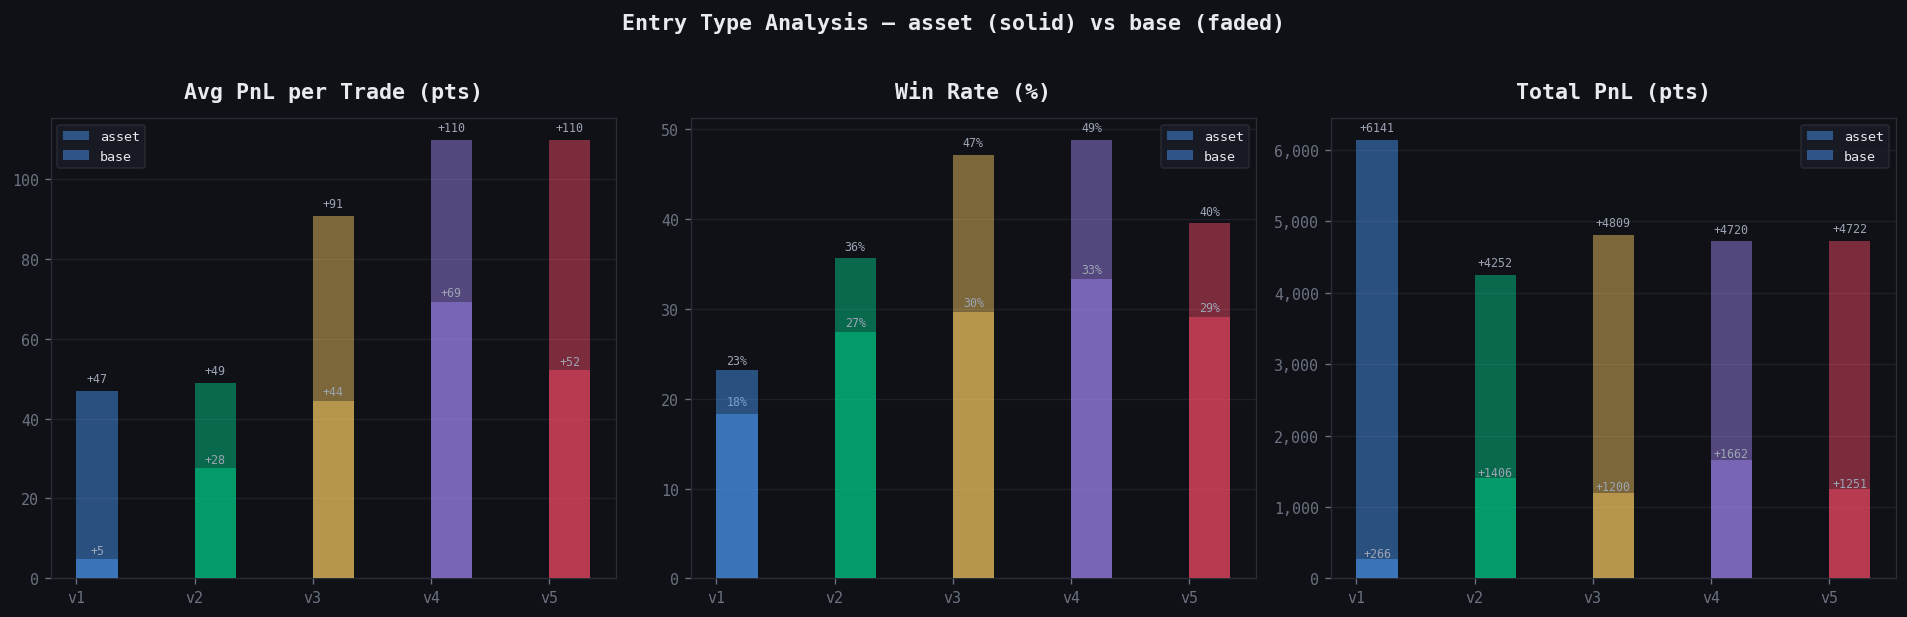

version entry_type  trades  total_pnl  avg_pnl  win_rate
     v1      asset     131    6141.00    46.88     18.32
     v1       base      56     266.00     4.75     23.21
     v2      asset      87    4252.50    48.88     35.63
     v2       base      51    1406.25    27.57     27.45
     v3      asset      53    4809.25    90.74     47.17
     v3       base      27    1200.50    44.46     29.63
     v4      asset      43    4719.75   109.76     48.84
     v4       base      24    1661.75    69.24     33.33
     v5      asset      43    4721.75   109.81     39.53
     v5       base      24    1250.75    52.11     29.17


In [ ]:
# ── Compute entry type stats ──────────────────────────────────────────────────
entry_rows = []
for ver in VERSIONS:
    df = dfs[ver]
    grp = df.groupby('entry_type').agg(
        trades    = ('pnl_points', 'count'),
        total_pnl = ('pnl_points', 'sum'),
        avg_pnl   = ('pnl_points', 'mean'),
        wins      = ('outcome', lambda x: (x=='WIN').sum()),
    ).reset_index()
    grp['win_rate'] = grp['wins'] / grp['trades'] * 100
    grp['version']  = ver
    entry_rows.append(grp)

entry_all = pd.concat(entry_rows, ignore_index=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
entry_types = ['asset', 'base']
metrics_e   = [('avg_pnl', 'Avg PnL per Trade (pts)'), ('win_rate', 'Win Rate (%)'), ('total_pnl', 'Total PnL (pts)')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

x_pos = np.arange(len(VERSIONS))
w = 0.35

for ax, (col, title) in zip(axes, metrics_e):
    ax.set_facecolor(BG)
    for j, et in enumerate(entry_types):
        vals   = []
        colors = []
        for ver in VERSIONS:
            sub = entry_all[(entry_all['version'] == ver) & (entry_all['entry_type'] == et)]
            vals.append(sub[col].values[0] if len(sub) > 0 else 0)
            colors.append(VERSION_COLORS[ver])

        alpha  = 1.0 if et == 'asset_psp' else 0.45
        offset = -w/2 if et == 'asset_psp' else w/2
        bars   = ax.bar(x_pos + offset, vals, width=w, color=colors, alpha=alpha,
                        label=et, zorder=3)

        for bar, val in zip(bars, vals):
            if abs(val) > 1:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + abs(max(vals)) * 0.02,
                        f'{val:+.0f}' if col != 'win_rate' else f'{val:.0f}%',
                        ha='center', fontsize=7, color='#9DA5B4')

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(VERSIONS)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', zorder=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Entry Type Analysis — asset (solid) vs base (faded)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('entry_type_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print(entry_all[['version','entry_type','trades','total_pnl','avg_pnl','win_rate']].round(2).to_string(index=False))


## [8] Asset & Directional Bias — All Versions

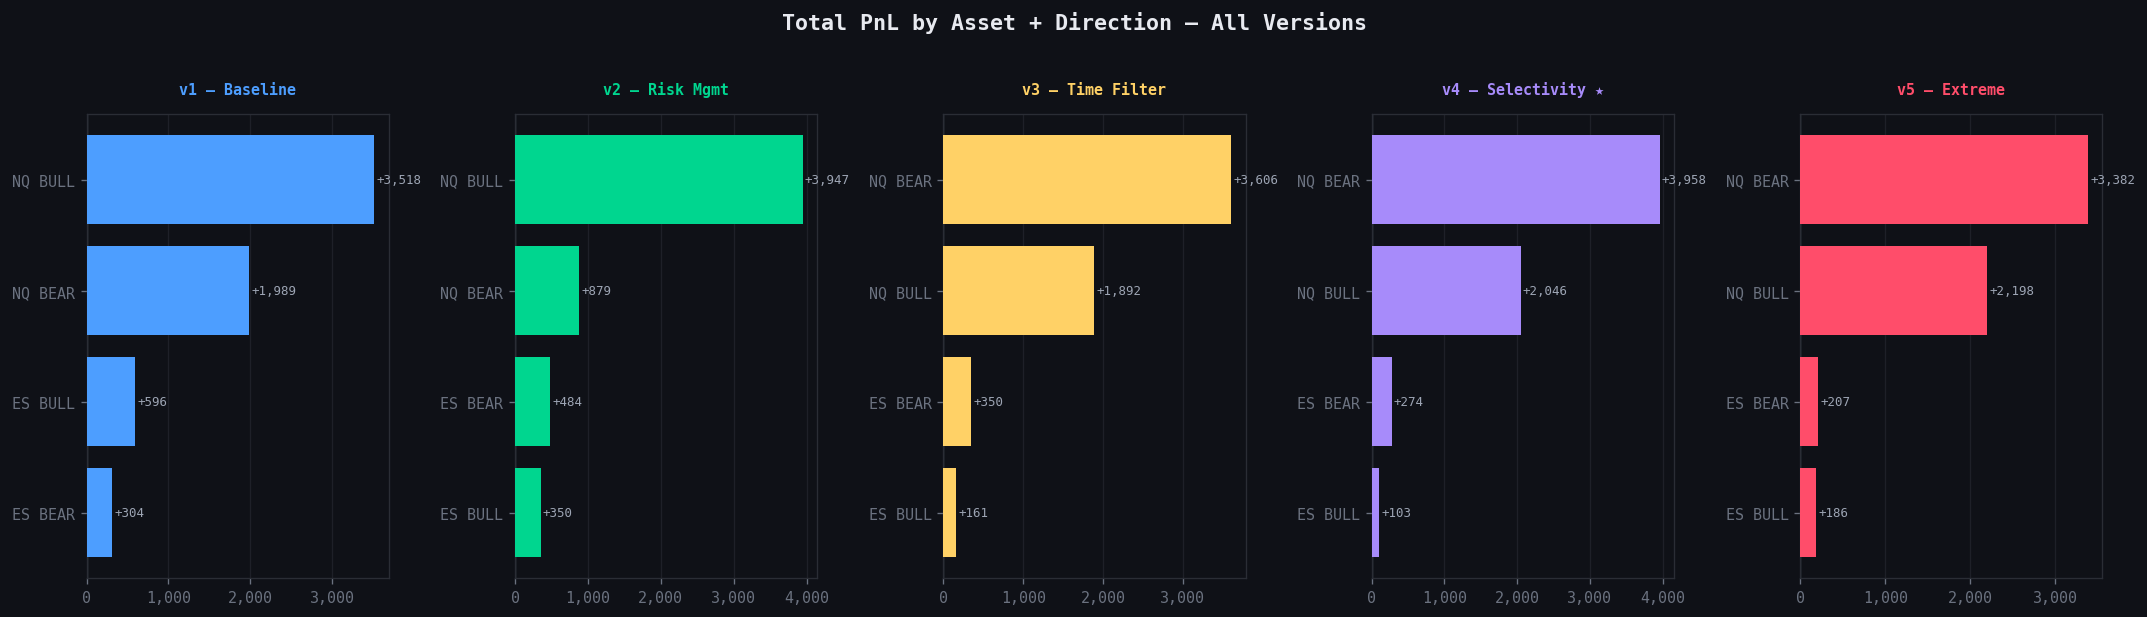

In [ ]:
fig, axes = plt.subplots(1, len(VERSIONS), figsize=(18, 5))
fig.patch.set_facecolor(BG)

for ax, ver in zip(axes, VERSIONS):
    df  = dfs[ver]
    col = VERSION_COLORS[ver]

    combo = df.groupby(['asset','bias']).agg(
        total_pnl = ('pnl_points','sum'),
        avg_pnl   = ('pnl_points','mean'),
        wins      = ('outcome', lambda x: (x=='WIN').sum()),
        trades    = ('pnl_points','count'),
    ).reset_index()
    combo['label']    = combo['asset'].str.upper() + ' ' + combo['bias'].str.upper()
    combo['win_rate'] = combo['wins'] / combo['trades'] * 100
    combo = combo.sort_values('total_pnl', ascending=True)

    bar_colors = [col if v >= 0 else RED for v in combo['total_pnl']]
    ax.set_facecolor(BG)
    bars = ax.barh(combo['label'], combo['total_pnl'], color=bar_colors, zorder=3)

    for bar, val in zip(bars, combo['total_pnl']):
        ax.text(val + (30 if val >= 0 else -30), bar.get_y() + bar.get_height()/2,
                f'{val:+,.0f}', va='center', fontsize=7.5, color='#9DA5B4')

    ax.axvline(0, color=GRAY, linewidth=0.8)
    ax.set_title(f'{VERSION_LABELS[ver]}', fontweight='bold', fontsize=9, color=col)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(True, axis='x', zorder=0)

plt.suptitle('Total PnL by Asset + Direction — All Versions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('asset_bias_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## [9] Time-of-Day Edge — All Versions

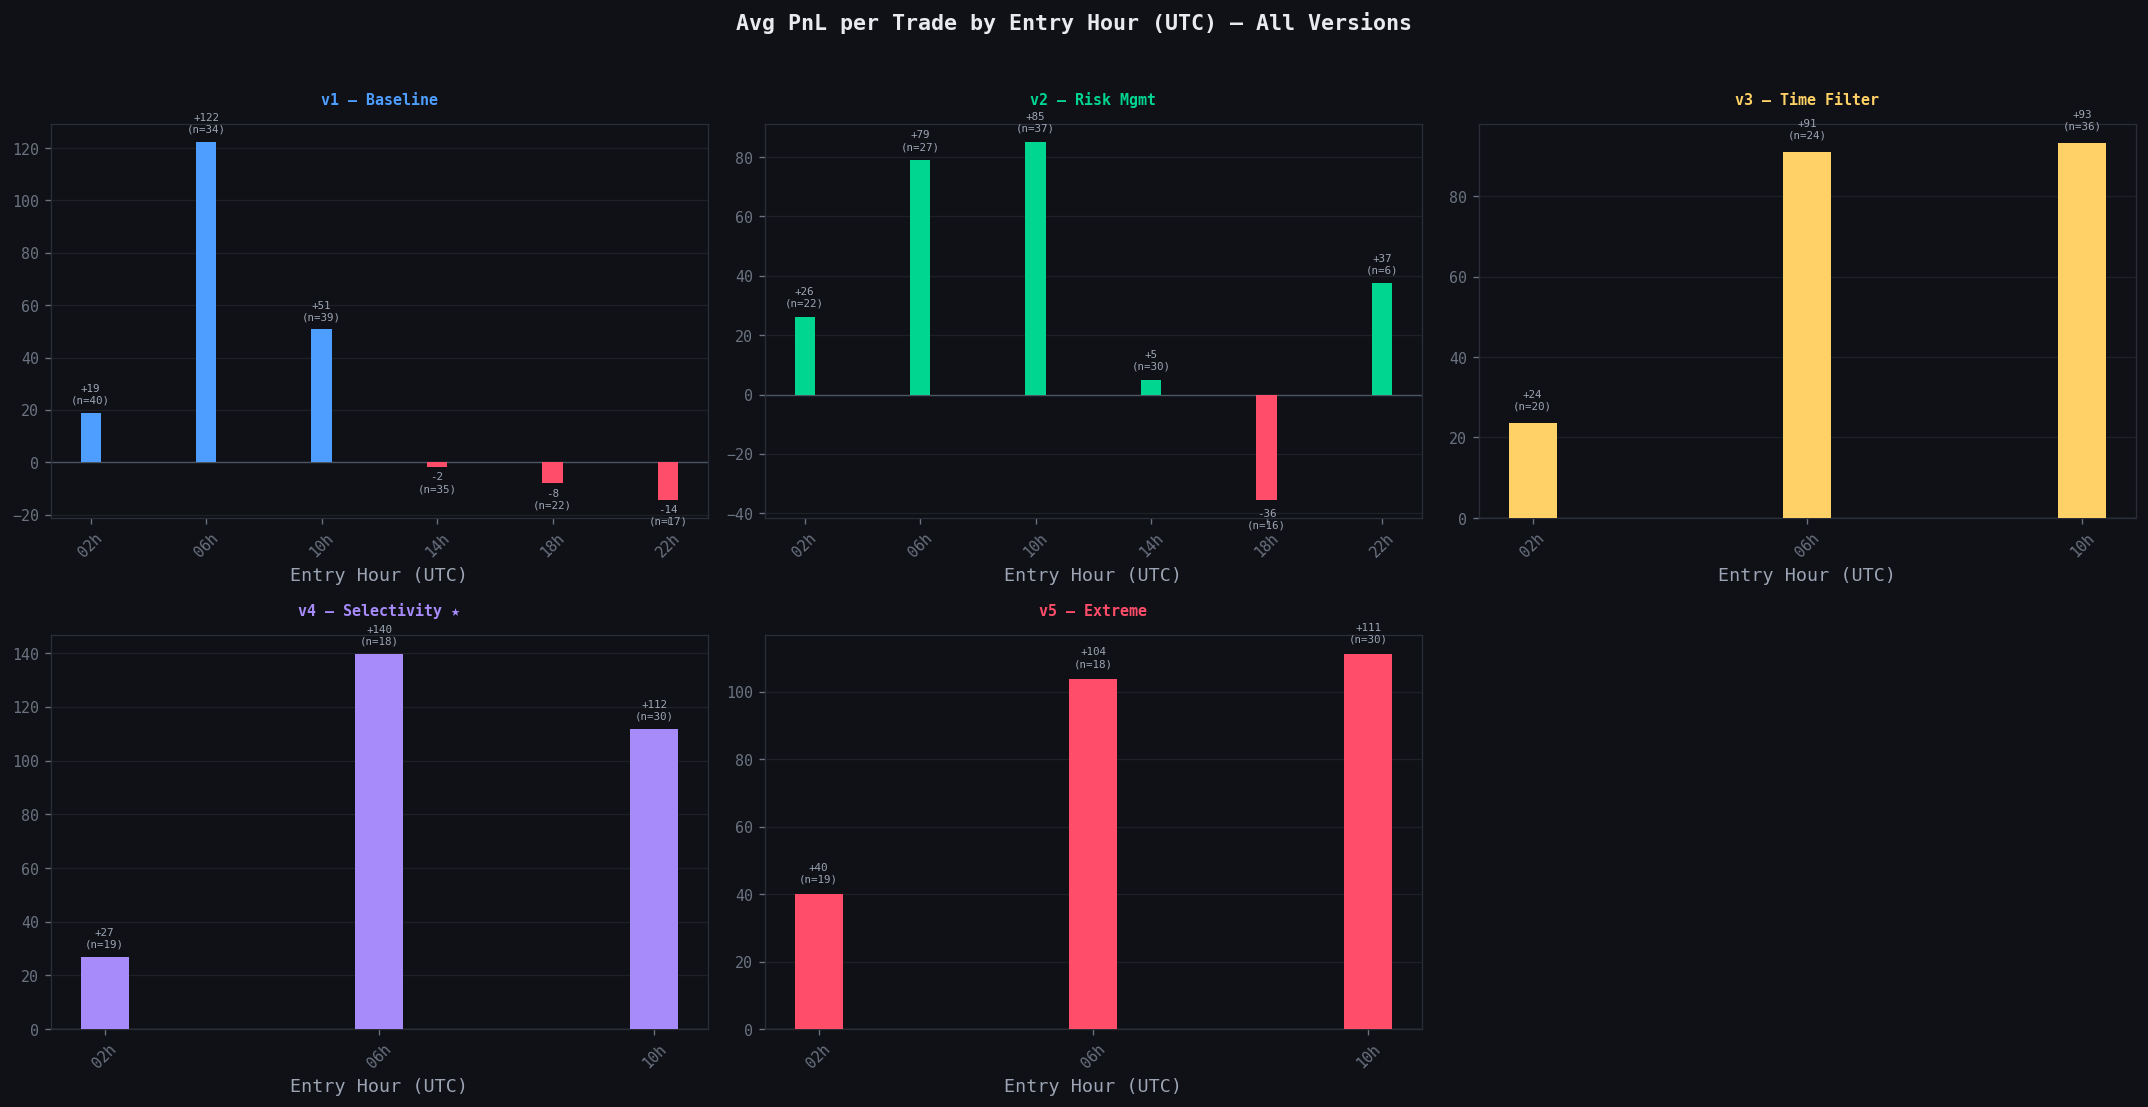

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.patch.set_facecolor(BG)
axes_flat = axes.flatten()

for i, ver in enumerate(VERSIONS):
    df  = dfs[ver]
    col = VERSION_COLORS[ver]
    ax  = axes_flat[i]

    hourly = df.groupby('entry_hour').agg(
        trades  = ('pnl_points','count'),
        avg_pnl = ('pnl_points','mean'),
    ).reset_index()

    bar_colors = [col if v >= 0 else RED for v in hourly['avg_pnl']]
    ax.set_facecolor(BG)
    bars = ax.bar(hourly['entry_hour'], hourly['avg_pnl'], color=bar_colors, width=0.7, zorder=3)

    for bar, val, cnt in zip(bars, hourly['avg_pnl'], hourly['trades']):
        ypos = bar.get_height() + 3 if val >= 0 else bar.get_height() - 10
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:+.0f}\n(n={cnt})', ha='center', va='bottom', fontsize=6.5, color='#9DA5B4')

    ax.axhline(0, color=GRAY, linewidth=0.8)
    ax.set_title(VERSION_LABELS[ver], fontweight='bold', fontsize=9, color=col)
    ax.set_xlabel('Entry Hour (UTC)')
    ax.set_xticks(hourly['entry_hour'])
    ax.set_xticklabels([f'{h:02d}h' for h in hourly['entry_hour']], rotation=45)
    ax.grid(True, axis='y', zorder=0)

# Turn off unused subplot
axes_flat[-1].set_visible(False)

plt.suptitle('Avg PnL per Trade by Entry Hour (UTC) — All Versions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hourly_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## [10] Breakeven Management — Dependency Evolution

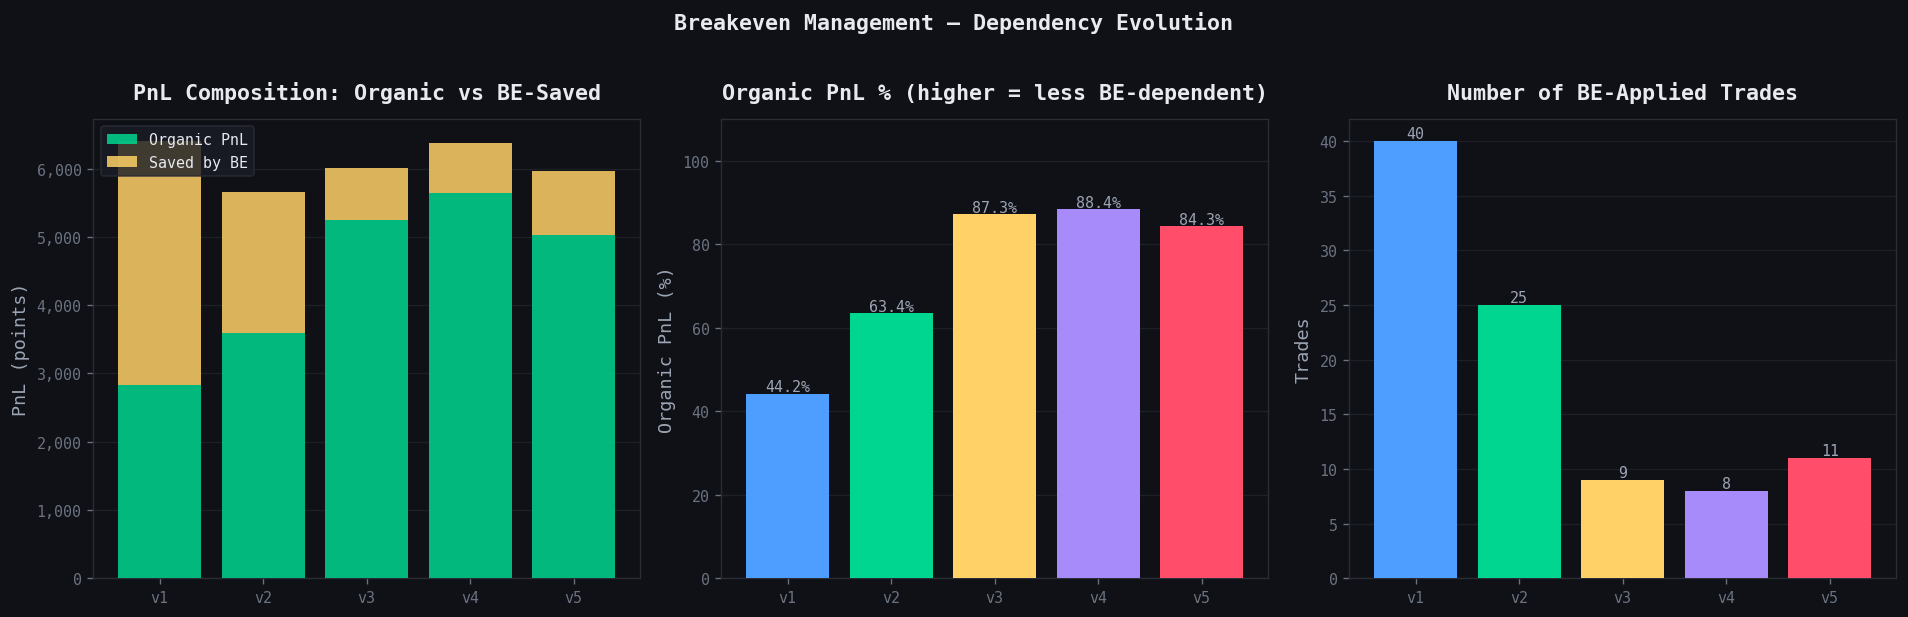

version  total_pnl  be_saved  organic  organic_pct  be_trades
     v1     6407.0    3572.2   2834.8         44.2         40
     v2     5658.8    2069.5   3589.2         63.4         25
     v3     6009.8     762.5   5247.2         87.3          9
     v4     6381.5     742.8   5638.8         88.4          8
     v5     5972.5     939.5   5033.0         84.3         11


In [ ]:
# ── Compute BE stats per version ─────────────────────────────────────────────
be_stats = []
for ver in VERSIONS:
    df = dfs[ver]
    if 'breakeven_applied' not in df.columns or 'risk_points' not in df.columns:
        continue
    be_trades    = df[df['breakeven_applied'] == True]
    be_cap_saved = be_trades['risk_points'].sum()
    total_pnl    = df['pnl_points'].sum()
    organic_pnl  = total_pnl - be_cap_saved
    be_stats.append({
        'version':      ver,
        'total_pnl':    total_pnl,
        'be_saved':     be_cap_saved,
        'organic':      organic_pnl,
        'organic_pct':  organic_pnl / total_pnl * 100,
        'be_pct':       be_cap_saved / total_pnl * 100,
        'be_trades':    len(be_trades),
    })

be_df = pd.DataFrame(be_stats)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

# Organic vs BE stacked bar
ax1 = axes[0]
ax1.set_facecolor(BG)
ax1.bar(be_df['version'], be_df['organic'], label='Organic PnL', color=GREEN, alpha=0.85, zorder=3)
ax1.bar(be_df['version'], be_df['be_saved'], bottom=be_df['organic'],
        label='Saved by BE', color=YELLOW, alpha=0.85, zorder=3)
ax1.set_title('PnL Composition: Organic vs BE-Saved', fontweight='bold')
ax1.set_ylabel('PnL (points)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(True, axis='y', zorder=0)

# Organic % trend
ax2 = axes[1]
ax2.set_facecolor(BG)
cols = [VERSION_COLORS[v] for v in be_df['version']]
bars = ax2.bar(be_df['version'], be_df['organic_pct'], color=cols, zorder=3)
for bar, val in zip(bars, be_df['organic_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=9, color='#9DA5B4')
ax2.set_title('Organic PnL % (higher = less BE-dependent)', fontweight='bold')
ax2.set_ylabel('Organic PnL (%)')
ax2.set_ylim(0, 110)
ax2.grid(True, axis='y', zorder=0)

# BE trades count
ax3 = axes[2]
ax3.set_facecolor(BG)
bars3 = ax3.bar(be_df['version'], be_df['be_trades'], color=cols, zorder=3)
for bar, val in zip(bars3, be_df['be_trades']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(val)), ha='center', fontsize=9, color='#9DA5B4')
ax3.set_title('Number of BE-Applied Trades', fontweight='bold')
ax3.set_ylabel('Trades')
ax3.grid(True, axis='y', zorder=0)

plt.suptitle('Breakeven Management — Dependency Evolution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('breakeven_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print(be_df[['version','total_pnl','be_saved','organic','organic_pct','be_trades']].round(1).to_string(index=False))


## [11] Trade Duration Analysis

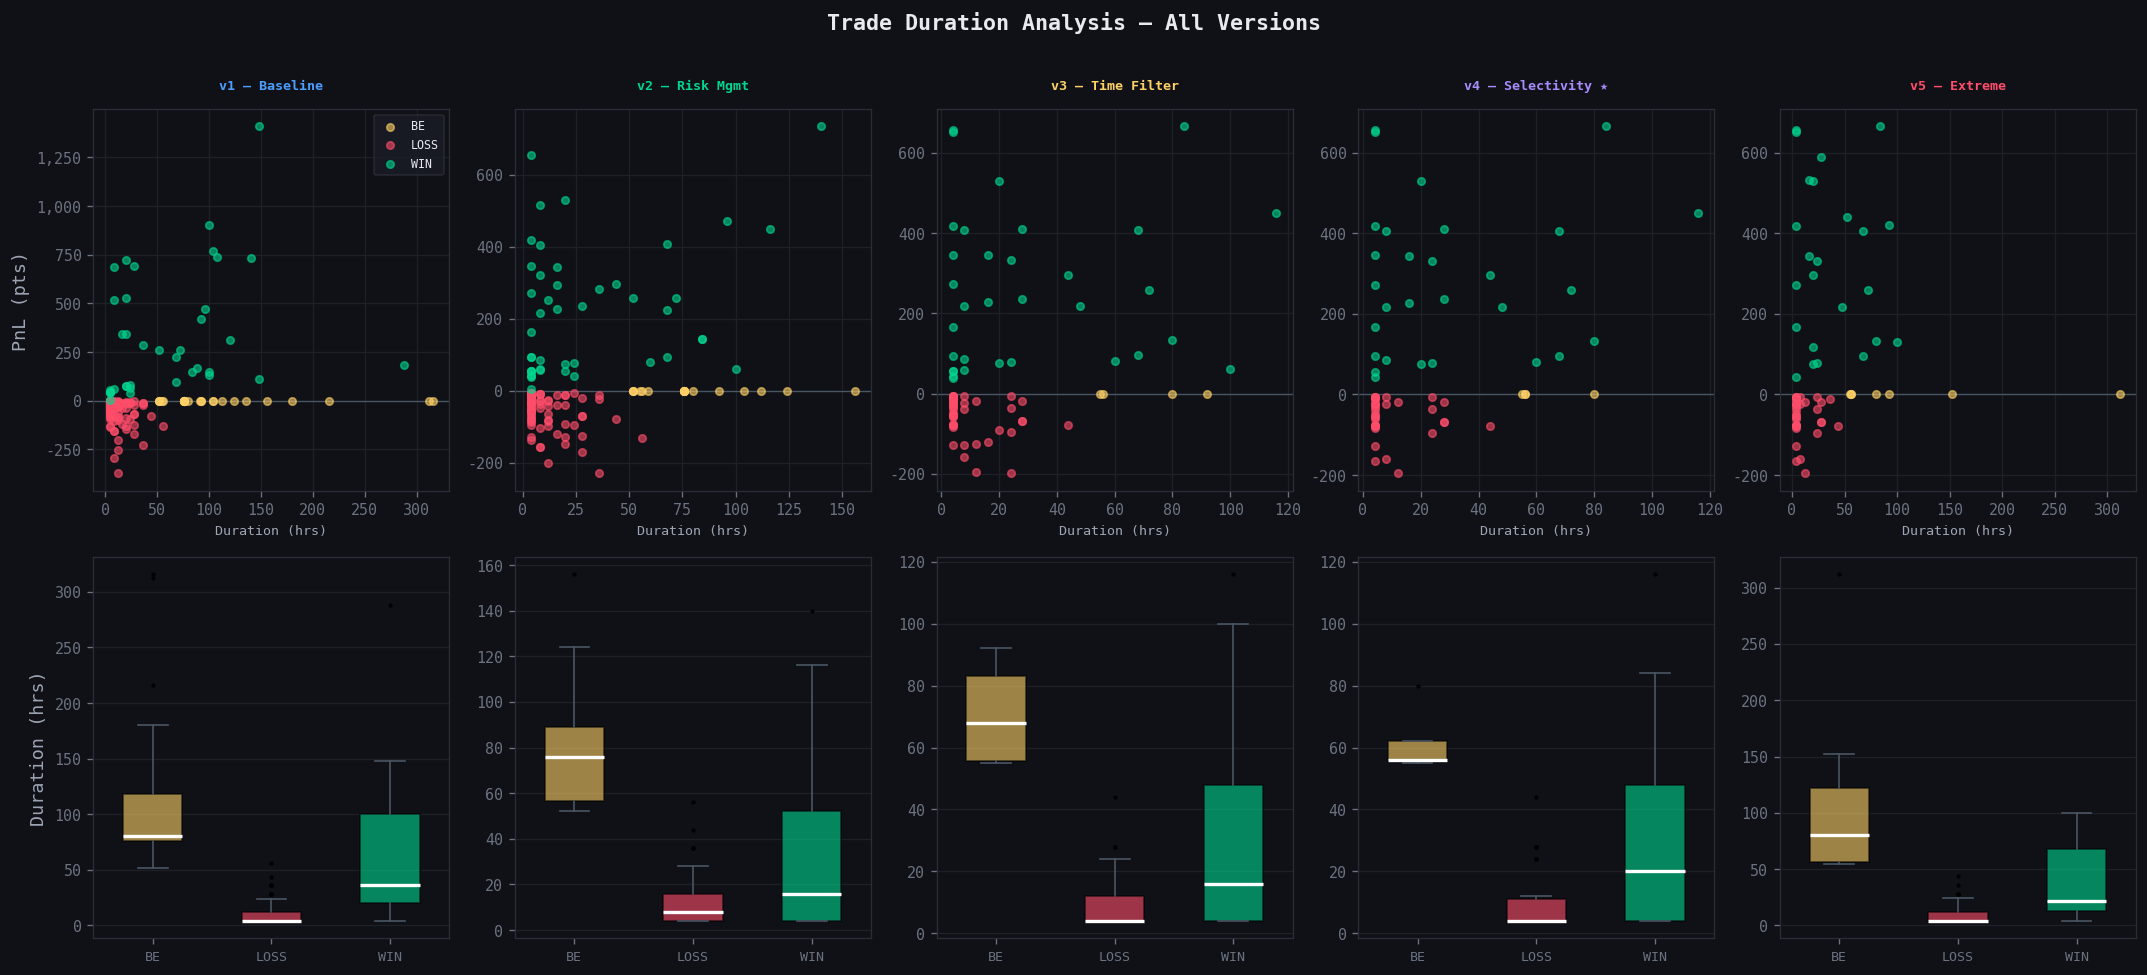

In [ ]:
outcome_colors = {'WIN': GREEN, 'LOSS': RED, 'BE': YELLOW}

fig, axes = plt.subplots(2, len(VERSIONS), figsize=(18, 8))
fig.patch.set_facecolor(BG)

for i, ver in enumerate(VERSIONS):
    df  = dfs[ver]
    col = VERSION_COLORS[ver]

    # Scatter: duration vs PnL
    ax_top = axes[0][i]
    ax_top.set_facecolor(BG)
    for outcome, grp in df.groupby('outcome'):
        ax_top.scatter(grp['duration_hrs'], grp['pnl_points'],
                       color=outcome_colors[outcome], alpha=0.6, s=20, label=outcome, zorder=3)
    ax_top.axhline(0, color=GRAY, linewidth=0.8)
    ax_top.set_title(VERSION_LABELS[ver], fontweight='bold', fontsize=8, color=col)
    ax_top.set_xlabel('Duration (hrs)', fontsize=8)
    ax_top.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax_top.grid(True, zorder=0)
    if i == 0:
        ax_top.set_ylabel('PnL (pts)')
        ax_top.legend(fontsize=7)

    # Box: duration by outcome
    ax_bot = axes[1][i]
    ax_bot.set_facecolor(BG)
    dur_by_outcome = df.groupby('outcome')['duration_hrs']
    for j, (outcome, grp) in enumerate(dur_by_outcome):
        ax_bot.boxplot(grp, positions=[j], widths=0.5, patch_artist=True,
                       boxprops=dict(facecolor=outcome_colors[outcome], alpha=0.6),
                       medianprops=dict(color='white', linewidth=2),
                       whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                       flierprops=dict(marker='.', color=GRAY, markersize=3))
    ax_bot.set_xticks([0, 1, 2])
    ax_bot.set_xticklabels(['BE', 'LOSS', 'WIN'], fontsize=8)
    ax_bot.grid(True, axis='y', zorder=0)
    if i == 0:
        ax_bot.set_ylabel('Duration (hrs)')

plt.suptitle('Trade Duration Analysis — All Versions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('duration_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## [12] Monte Carlo Simulations — All Versions

In [ ]:
N_SIMULATIONS = 10_000
N_TRADES      = 200
np.random.seed(42)

mc_results = {}

for ver in VERSIONS:
    pnl = dfs[ver]['pnl_points'].values
    sims = np.zeros((N_SIMULATIONS, N_TRADES))
    for i in range(N_SIMULATIONS):
        sims[i] = np.cumsum(np.random.choice(pnl, size=N_TRADES, replace=True))

    final_pnls  = sims[:, -1]
    prob_profit = (final_pnls > 0).mean() * 100

    def max_dd(curve):
        peak = np.maximum.accumulate(curve)
        return (curve - peak).min()

    all_dd = np.array([max_dd(sims[i]) for i in range(N_SIMULATIONS)])

    mc_results[ver] = {
        'sims':        sims,
        'final_pnls':  final_pnls,
        'all_dd':      all_dd,
        'prob_profit': prob_profit,
        'median':      np.median(final_pnls),
        'p5':          np.percentile(final_pnls, 5),
        'p95':         np.percentile(final_pnls, 95),
        'median_dd':   np.median(all_dd),
        'worst_1pct':  np.percentile(all_dd, 1),
        'med_curve':   np.median(sims, axis=0),
        'p5_curve':    np.percentile(sims, 5,  axis=0),
        'p95_curve':   np.percentile(sims, 95, axis=0),
    }

    print(f'{ver}: P(profit)={prob_profit:.1f}%  Median={np.median(final_pnls):+,.0f}  '
          f'P5={np.percentile(final_pnls,5):+,.0f}  P95={np.percentile(final_pnls,95):+,.0f}  '
          f'MedianDD={np.median(all_dd):,.0f}  Worst1%DD={np.percentile(all_dd,1):,.0f}')

print(f'\n✅ Monte Carlo complete: {N_SIMULATIONS:,} simulations × {N_TRADES} trades each.')


v1: P(profit)=99.5%  Median=+6,753  P5=+2,183  P95=+11,835  MedianDD=-1,081  Worst1%DD=-2,608
v2: P(profit)=100.0%  Median=+8,126  P5=+4,424  P95=+12,271  MedianDD=-766  Worst1%DD=-1,695
v3: P(profit)=100.0%  Median=+14,992  P5=+10,522  P95=+19,664  MedianDD=-602  Worst1%DD=-1,256
v4: P(profit)=100.0%  Median=+18,956  P5=+14,232  P95=+23,993  MedianDD=-517  Worst1%DD=-1,053
v5: P(profit)=100.0%  Median=+17,763  P5=+12,761  P95=+22,929  MedianDD=-570  Worst1%DD=-1,148

✅ Monte Carlo complete: 10,000 simulations × 200 trades each.


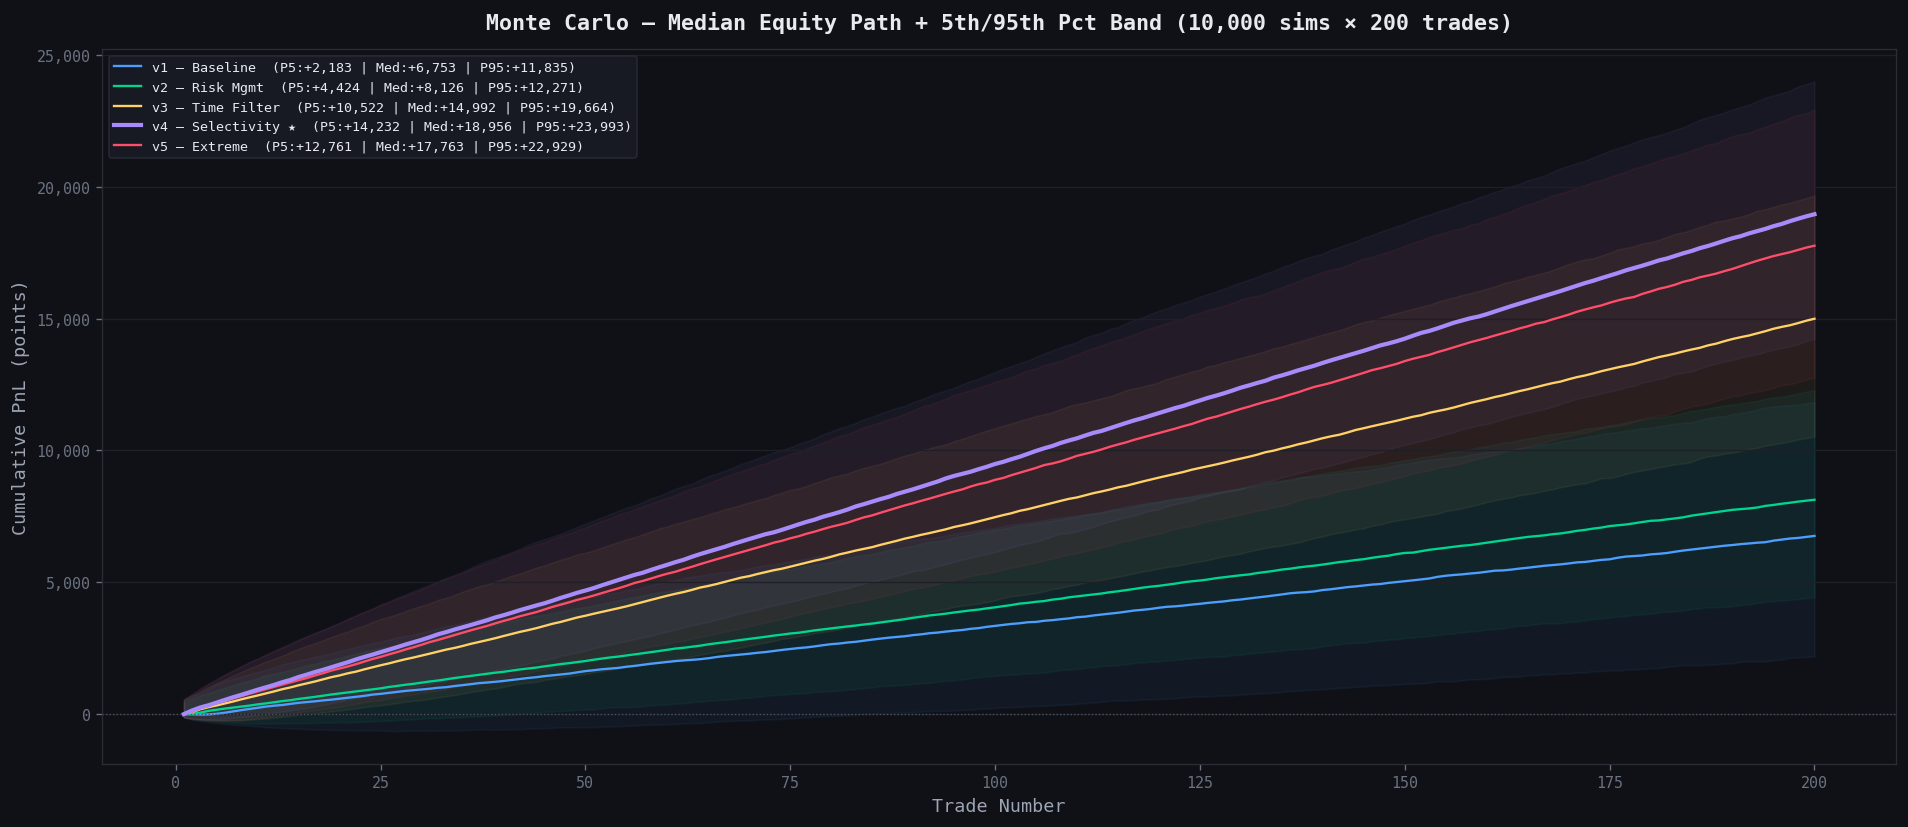

In [ ]:
# ── Plot 1: Median equity fan per version ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

trades_x = np.arange(1, N_TRADES + 1)
for ver in VERSIONS:
    r   = mc_results[ver]
    col = VERSION_COLORS[ver]
    lw  = 2.5 if ver == 'v4' else 1.4
    ax.fill_between(trades_x, r['p5_curve'], r['p95_curve'], color=col, alpha=0.06)
    ax.plot(trades_x, r['med_curve'], color=col, linewidth=lw,
            label=f"{VERSION_LABELS[ver]}  (P5:{r['p5']:+,.0f} | Med:{r['median']:+,.0f} | P95:{r['p95']:+,.0f})",
            zorder=3 if ver=='v4' else 2)

ax.axhline(0, color=GRAY, linewidth=0.8, linestyle=':')
ax.set_title(f'Monte Carlo — Median Equity Path + 5th/95th Pct Band ({N_SIMULATIONS:,} sims × {N_TRADES} trades)',
             fontweight='bold')
ax.set_xlabel('Trade Number')
ax.set_ylabel('Cumulative PnL (points)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('mc_fan_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


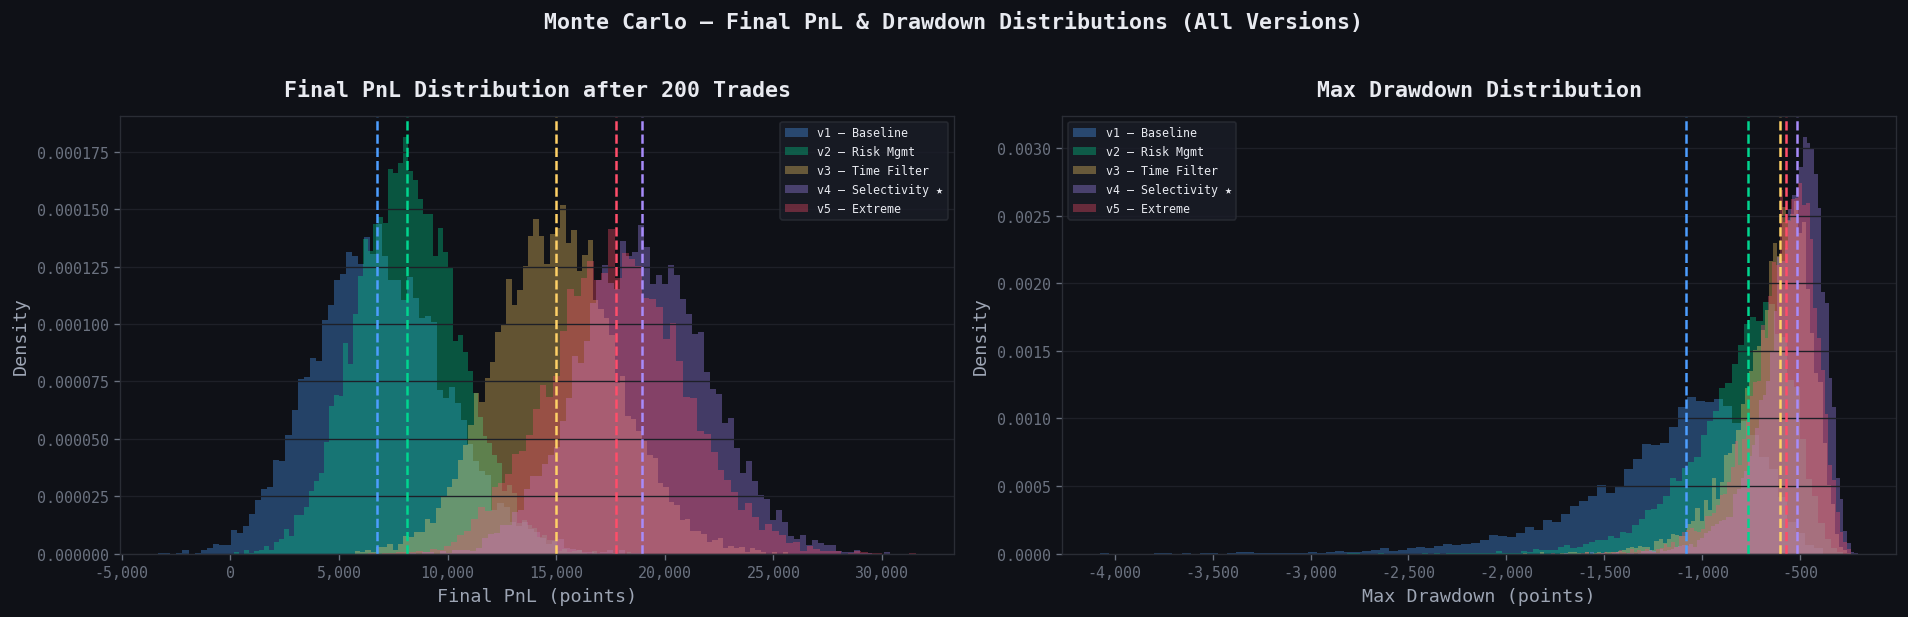

In [ ]:
# ── Plot 2: Final PnL distribution overlay ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG)

# KDE-like histogram overlay
ax1 = axes[0]
ax1.set_facecolor(BG)
for ver in VERSIONS:
    ax1.hist(mc_results[ver]['final_pnls'], bins=80, alpha=0.35,
             color=VERSION_COLORS[ver], label=VERSION_LABELS[ver], density=True)
    med = mc_results[ver]['median']
    ax1.axvline(med, color=VERSION_COLORS[ver], linewidth=1.5, linestyle='--')

ax1.set_title(f'Final PnL Distribution after {N_TRADES} Trades', fontweight='bold')
ax1.set_xlabel('Final PnL (points)')
ax1.set_ylabel('Density')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=7)
ax1.grid(True, axis='y')

# Max drawdown distribution overlay
ax2 = axes[1]
ax2.set_facecolor(BG)
for ver in VERSIONS:
    ax2.hist(mc_results[ver]['all_dd'], bins=80, alpha=0.35,
             color=VERSION_COLORS[ver], label=VERSION_LABELS[ver], density=True)
    med_dd = mc_results[ver]['median_dd']
    ax2.axvline(med_dd, color=VERSION_COLORS[ver], linewidth=1.5, linestyle='--')

ax2.set_title('Max Drawdown Distribution', fontweight='bold')
ax2.set_xlabel('Max Drawdown (points)')
ax2.set_ylabel('Density')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.legend(fontsize=7)
ax2.grid(True, axis='y')

plt.suptitle('Monte Carlo — Final PnL & Drawdown Distributions (All Versions)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mc_dist_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


In [ ]:
# ── MC Summary Table ──────────────────────────────────────────────────────────
print('=' * 90)
print(f"  {'MONTE CARLO SUMMARY — ALL VERSIONS':^86}")
print(f"  {N_SIMULATIONS:,} simulations × {N_TRADES} trades each")
print('=' * 90)
mc_metrics = [
    ('P(profit)',         'prob_profit',  '{:.1f}%'),
    ('Median final PnL',  'median',       '{:+,.0f}'),
    ('5th pct PnL',       'p5',           '{:+,.0f}'),
    ('95th pct PnL',      'p95',          '{:+,.0f}'),
    ('Median max DD',     'median_dd',    '{:,.0f}'),
    ('Worst 1% DD',       'worst_1pct',   '{:,.0f}'),
]
header = f"  {'Metric':<22}" + ''.join(f"  {v:>13}" for v in VERSIONS)
print(header)
print('-' * 90)
for label, key, fmt in mc_metrics:
    row = f"  {label:<22}"
    for v in VERSIONS:
        row += f"  {fmt.format(mc_results[v][key]):>13}"
    print(row)
print('=' * 90)


                            MONTE CARLO SUMMARY — ALL VERSIONS                          
  10,000 simulations × 200 trades each
  Metric                             v1             v2             v3             v4             v5
------------------------------------------------------------------------------------------
  P(profit)                       99.5%         100.0%         100.0%         100.0%         100.0%
  Median final PnL               +6,753         +8,126        +14,992        +18,956        +17,763
  5th pct PnL                    +2,183         +4,424        +10,522        +14,232        +12,761
  95th pct PnL                  +11,835        +12,271        +19,664        +23,993        +22,929
  Median max DD                  -1,081           -766           -602           -517           -570
  Worst 1% DD                    -2,608         -1,695         -1,256         -1,053         -1,148


## [13] Optimisation Summary

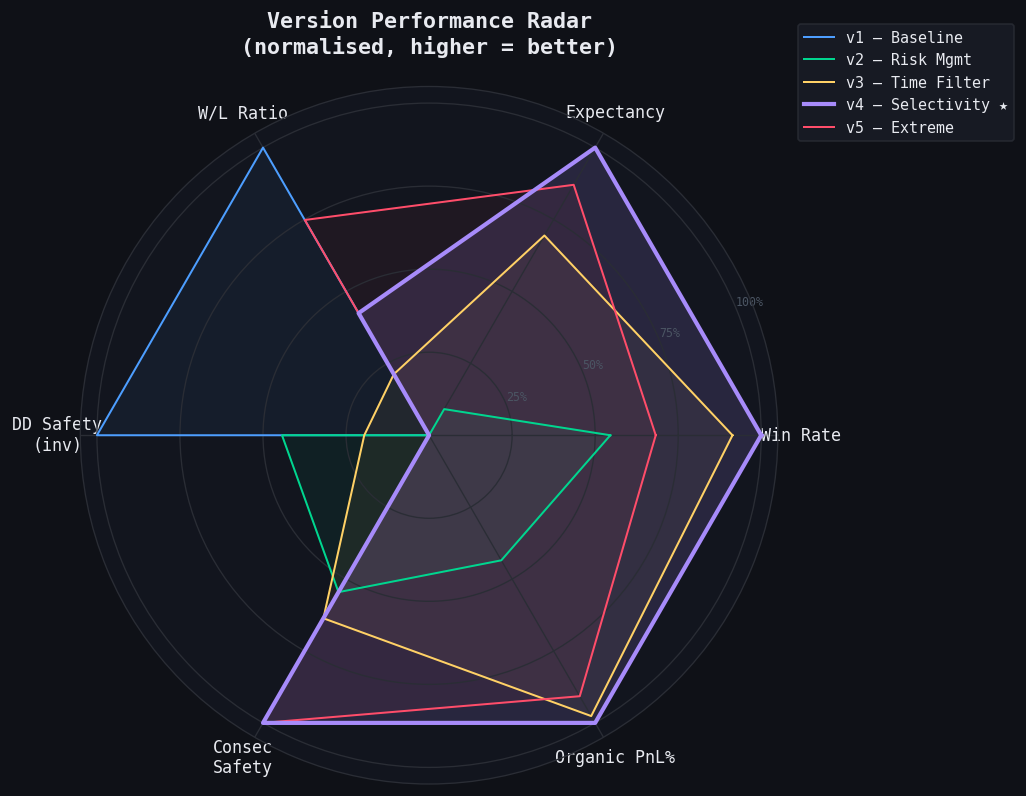

In [ ]:
# ── Radar / spider chart — normalised metrics ─────────────────────────────────
from matplotlib.patches import FancyArrowPatch

radar_metrics = {
    'Win Rate':         ('win_rate',    False),   # (col, invert?)
    'Expectancy':       ('expectancy',  False),
    'W/L Ratio':        ('wl_ratio',    False),
    'DD Safety\n(inv)': ('max_dd',      True),    # inverted: lower DD = better
    'Consec\nSafety':   ('max_consec',  True),    # inverted: fewer losses = better
    'Organic PnL%':     ('organic_pct', False),
}

labels = list(radar_metrics.keys())
N_radar = len(labels)
angles  = np.linspace(0, 2 * np.pi, N_radar, endpoint=False).tolist()
angles += angles[:1]

# Normalise each metric 0–1 across all versions
norm_vals = {}
for col_label, (col, invert) in radar_metrics.items():
    vals = np.array([summary.loc[v, col] for v in VERSIONS])
    mn, mx = vals.min(), vals.max()
    normed = (vals - mn) / (mx - mn) if mx != mn else np.ones_like(vals) * 0.5
    if invert:
        normed = 1 - normed
    norm_vals[col_label] = normed

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG)
ax.set_facecolor('#12151E')

for j, ver in enumerate(VERSIONS):
    values = [norm_vals[m][j] for m in labels] + [norm_vals[labels[0]][j]]
    col = VERSION_COLORS[ver]
    lw  = 2.5 if ver == 'v4' else 1.2
    ax.plot(angles, values, color=col, linewidth=lw, label=VERSION_LABELS[ver],
            zorder=3 if ver=='v4' else 2)
    ax.fill(angles, values, color=col, alpha=0.06 if ver != 'v4' else 0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10, color='#E8EAF0')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7, color='#4B5563')
ax.grid(color='#2A2D35', linewidth=0.8)
ax.spines['polar'].set_color('#2A2D35')
ax.set_title('Version Performance Radar\n(normalised, higher = better)', fontweight='bold',
             fontsize=13, color='#E8EAF0', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig('radar_all.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


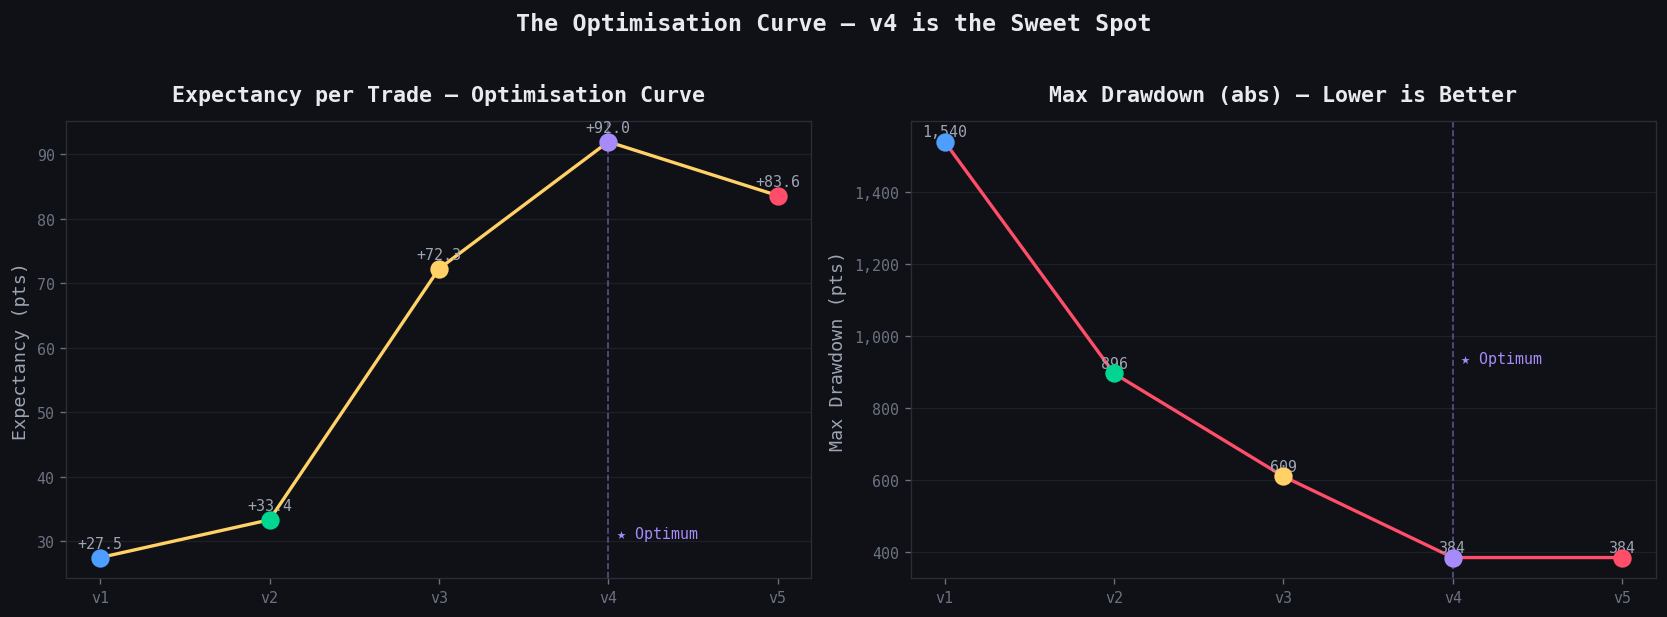


  CONCLUSION
  Expectancy improvement (v1→v4) : +234%
  Drawdown improvement   (v1→v4) : -75%
  Win rate improvement   (v1→v4) : +23.5pp
  Trade count reduction  (v1→v4) : -64%
  MC P(profit) at v4             : 100.0%
  MC median PnL at v4 (×200)     : +18,956 pts
  ★ v4 (min RR=4 + data quality) is the optimal engine.
  v5 over-filters — win rate regresses despite higher RR.


In [ ]:
# ── Final summary: the optimisation curve ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)

xv = np.arange(len(VERSIONS))
cols_v = [VERSION_COLORS[v] for v in VERSIONS]

# Expectancy curve
ax1 = axes[0]
ax1.set_facecolor(BG)
exp_vals = [summary.loc[v, 'expectancy'] for v in VERSIONS]
ax1.plot(VERSIONS, exp_vals, color=YELLOW, linewidth=2, marker='o', markersize=8, zorder=3)
for i, (v, val) in enumerate(zip(VERSIONS, exp_vals)):
    ax1.scatter(v, val, color=VERSION_COLORS[v], s=100, zorder=4)
    ax1.text(i, val + 1.5, f'+{val:.1f}', ha='center', fontsize=9, color='#9DA5B4')
ax1.axvline(VERSIONS.index('v4'), color=VERSION_COLORS['v4'], linestyle='--', alpha=0.5, linewidth=1)
ax1.text(VERSIONS.index('v4') + 0.05, min(exp_vals) + 3, '★ Optimum', fontsize=9, color=VERSION_COLORS['v4'])
ax1.set_title('Expectancy per Trade — Optimisation Curve', fontweight='bold')
ax1.set_ylabel('Expectancy (pts)')
ax1.grid(True, axis='y')

# Drawdown reduction
ax2 = axes[1]
ax2.set_facecolor(BG)
dd_vals = [abs(summary.loc[v, 'max_dd']) for v in VERSIONS]
ax2.plot(VERSIONS, dd_vals, color=RED, linewidth=2, marker='o', markersize=8, zorder=3)
for i, (v, val) in enumerate(zip(VERSIONS, dd_vals)):
    ax2.scatter(v, val, color=VERSION_COLORS[v], s=100, zorder=4)
    ax2.text(i, val + 15, f'{val:,.0f}', ha='center', fontsize=9, color='#9DA5B4')
ax2.axvline(VERSIONS.index('v4'), color=VERSION_COLORS['v4'], linestyle='--', alpha=0.5, linewidth=1)
ax2.text(VERSIONS.index('v4') + 0.05, max(dd_vals) * 0.6, '★ Optimum', fontsize=9, color=VERSION_COLORS['v4'])
ax2.set_title('Max Drawdown (abs) — Lower is Better', fontweight='bold')
ax2.set_ylabel('Max Drawdown (pts)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(True, axis='y')

plt.suptitle('The Optimisation Curve — v4 is the Sweet Spot', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('optimisation_curve.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Final print ───────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('  CONCLUSION')
print('=' * 60)
v4 = summary.loc['v4']
v1 = summary.loc['v1']
print(f"  Expectancy improvement (v1→v4) : {(v4['expectancy']-v1['expectancy'])/v1['expectancy']*100:+.0f}%")
print(f"  Drawdown improvement   (v1→v4) : {(abs(v4['max_dd'])-abs(v1['max_dd']))/abs(v1['max_dd'])*100:+.0f}%")
print(f"  Win rate improvement   (v1→v4) : {v4['win_rate']-v1['win_rate']:+.1f}pp")
print(f"  Trade count reduction  (v1→v4) : {(v4['trades']-v1['trades'])/v1['trades']*100:+.0f}%")
print(f"  MC P(profit) at v4             : {mc_results['v4']['prob_profit']:.1f}%")
print(f"  MC median PnL at v4 (×200)     : {mc_results['v4']['median']:+,.0f} pts")
print('=' * 60)
print('  ★ v4 (min RR=4 + data quality) is the optimal engine.')
print('  v5 over-filters — win rate regresses despite higher RR.')
print('=' * 60)
